In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
import os
from google.colab import drive
import pandas as pd
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/train.csv'
df = None
if os.path.exists(file_path):
  print(f"File {file_path} found. Reading data.")
  df = pd.read_csv(file_path)
  display(df.head())
else:
  print(f"The file {file_path} was not found in your Google Drive. Please check the path and ensure the file exists.")
  print("Make sure you have mounted Google Drive and provided the correct path.")



Mounted at /content/drive
File /content/drive/MyDrive/train.csv found. Reading data.


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:

if df is not None:
    df.info()
    df.describe()
else:
    print("DataFrame 'df' is None. Please ensure the sales.csv file is loaded correctly.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [15]:
if df is not None:
    df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=True)
    df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed', dayfirst=True)
    df = df.drop_duplicates()

    df = df.fillna(0)

    df.info()
else:
    print("DataFrame 'df' is None. Please ensure the sales.csv file is loaded correctly before cleaning.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9800 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [ ]:
if df is not None:
    print("Total Sales:", df['Sales'].sum())
    print("Average Sales:", df['Sales'].mean())
    print("Maximum Sales:", df['Sales'].max())
    print("Minimum Sales:", df['Sales'].min())
else:
    print("DataFrame 'df' is None. Cannot perform sales calculations.")

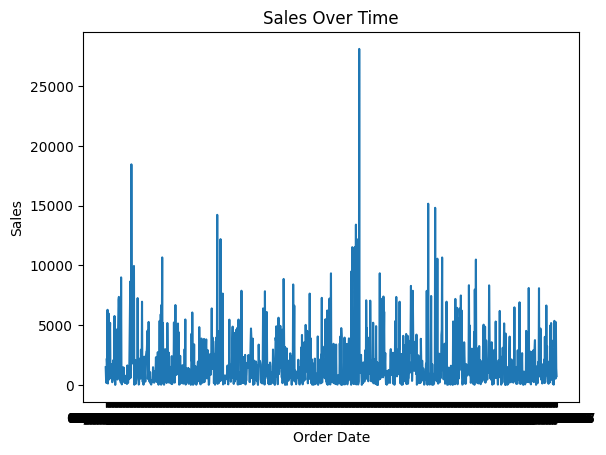

In [6]:
if df is not None:
    trend = df.groupby('Order Date')['Sales'].sum().reset_index()

    plt.figure()
    plt.plot(trend['Order Date'], trend['Sales'])
    plt.title("Sales Over Time")
    plt.xlabel("Order Date")
    plt.ylabel("Sales")
    plt.show()
else:
    print("DataFrame 'df' is None. Cannot plot sales trend.")

In [7]:
if df is not None:
    df['Month'] = df['Order Date'].dt.month

    monthly = df.groupby('Month')['Sales'].sum().reset_index()

    plt.figure()
    plt.plot(monthly['Month'], monthly['Sales'])
    plt.title("Monthly Sales Trend")
    plt.xlabel("Month")
    plt.ylabel("Sales")
    plt.show()
else:
    print("DataFrame 'df' is None. Cannot plot monthly sales trend.")

AttributeError: Can only use .dt accessor with datetimelike values

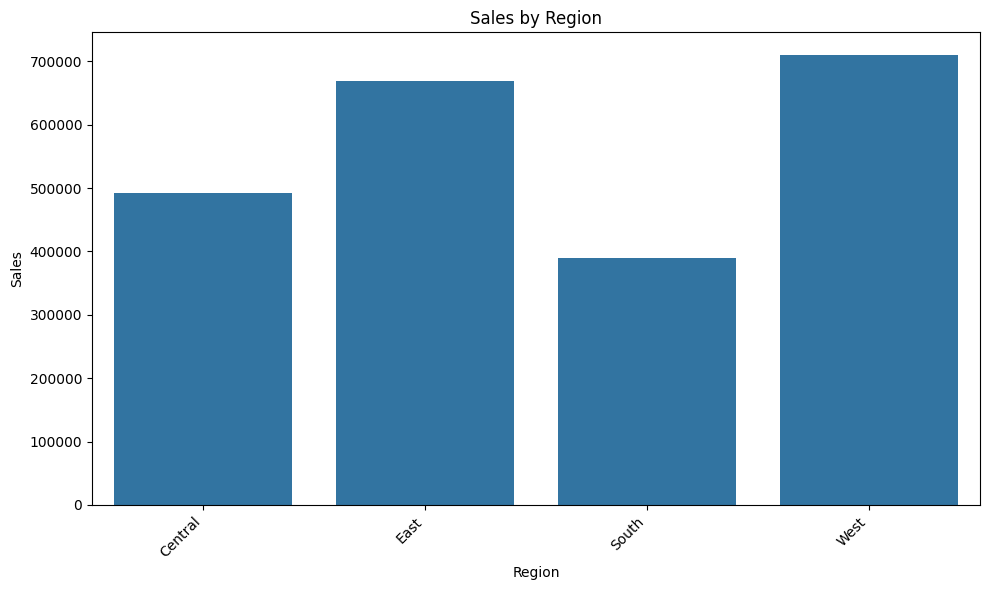

In [8]:
if df is not None:
    store_sales = df.groupby('Region')['Sales'].sum().reset_index()

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Region', y='Sales', data=store_sales)
    plt.title("Sales by Region")
    plt.xlabel("Region")
    plt.ylabel("Sales")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("DataFrame 'df' is None. Cannot plot sales by region.")

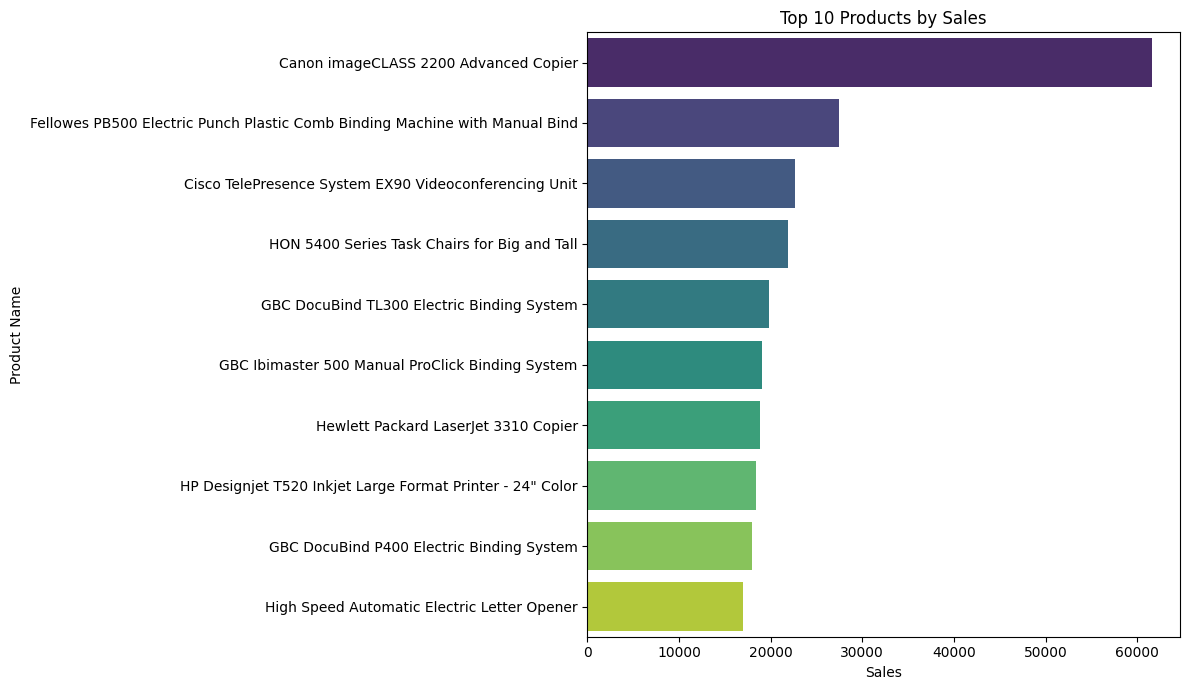

In [16]:
if df is not None:
    item_sales = df.groupby('Product Name')['Sales'].sum().reset_index()

    top_items = item_sales.sort_values(by='Sales', ascending=False).head(10)

    plt.figure(figsize=(12, 7))
    sns.barplot(x='Sales', y='Product Name', data=top_items, palette='viridis', hue='Product Name', legend=False)
    plt.title("Top 10 Products by Sales")
    plt.xlabel("Sales")
    plt.ylabel("Product Name")
    plt.tight_layout()
    plt.show()
else:
    print("DataFrame 'df' is None. Cannot plot top items.")

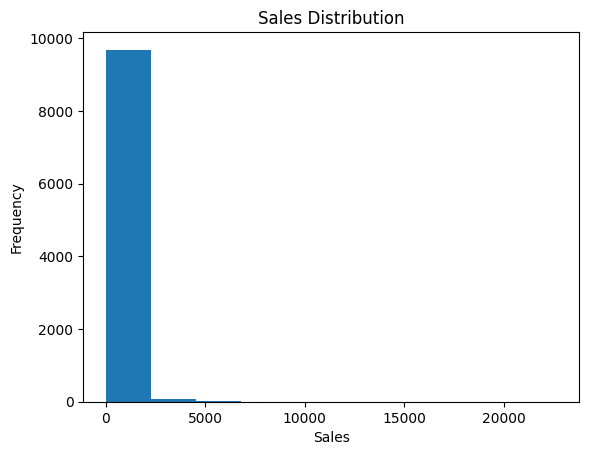

In [12]:
if df is not None:
    plt.figure()
    plt.hist(df['Sales'])
    plt.title("Sales Distribution")
    plt.xlabel("Sales")
    plt.ylabel("Frequency")
    plt.show()
else:
    print("DataFrame 'df' is None. Cannot plot sales distribution.")

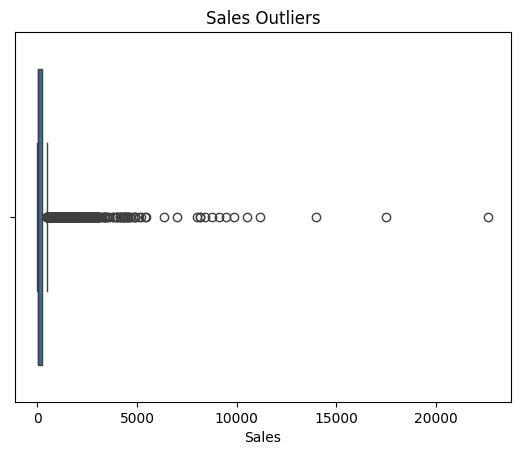

In [11]:
if df is not None:
    plt.figure()
    sns.boxplot(x=df['Sales'])
    plt.title("Sales Outliers")
    plt.show()
else:
    print("DataFrame 'df' is None. Cannot plot sales outliers.")

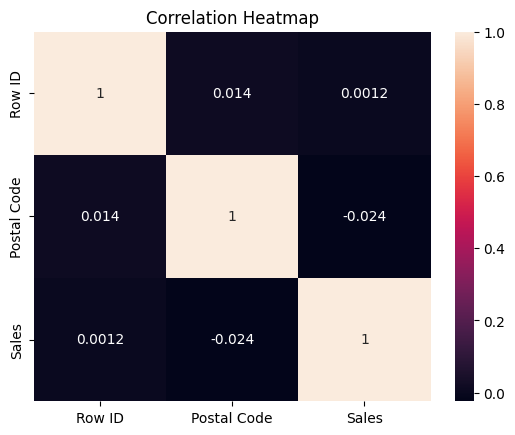

In [13]:
if df is not None:
    corr = df.corr(numeric_only=True)

    plt.figure()
    sns.heatmap(corr, annot=True)
    plt.title("Correlation Heatmap")
    plt.show()
else:
    print("DataFrame 'df' is None. Cannot create correlation heatmap.")

In [10]:
if 'trend' in locals() and trend is not None:
    fig = px.line(trend, x='Order Date', y='Sales', title='Interactive Sales Trend')
    fig.show()
else:
    print("Variable 'trend' is not available or is None. Ensure 'df' is loaded and the sales trend is calculated.")